# AI Study Planner

An intelligent study planning system that generates optimized schedules based on subject deadlines, difficulty levels, and workload constraints.

## Problem Statement

Students often struggle to plan their studies effectively. They either overload themselves or fail to complete subjects on time.

This project solves that problem by automatically generating a balanced and efficient study schedule.

## Features

- Smart scheduling using priority logic
- Daily workload limit handling
- Revision planning before exams
- Overload detection
- Burnout risk warning
- Data visualization

## Approach

- Collect subject details (deadline, hours required, difficulty)
- Prioritize subjects based on urgency and difficulty
- Distribute study hours dynamically
- Ensure daily workload limit is not exceeded
- Add revision sessions before exams

## Algorithm

1. Calculate remaining hours for each subject
2. Determine days left until deadline
3. Allocate study time proportionally
4. Adjust based on difficulty level
5. Repeat daily until all tasks are completed

Enter number of subjects: 1

Subject 1
Name: ss
Days left: 4
Total hours needed: 4
Difficulty (1-5): 5

✅ Subjects Entered:
{'name': 'ss', 'deadline': 4, 'hours': 4.0, 'difficulty': 5}

Total Required: 4.0
Max Possible: 96

✅ STUDY HOURS CHECK:
subject
ss    4.0
Name: hours, dtype: float64

📊 SUBJECT-WISE TOTAL:
subject
ss    5.5
Name: hours, dtype: float64

📊 STUDY vs REVISION:
subject  type    
ss       revision    1.5
         study       4.0
Name: hours, dtype: float64

📋 CLEAN SUMMARY:


type,revision,study,total
subject,,,
ss,1.5,4.0,5.5



📈 COMPLETION %:
ss: 100.0%

===== STUDY PLAN =====



,day,subject,hours,type
0,1,ss,1.0,study
1,2,ss,1.0,study
2,3,ss,1.0,study
3,3,ss,1.5,revision
4,4,ss,1.0,study



📅 Day 1
ss - 1.0 hrs (study)

📅 Day 2
ss - 1.0 hrs (study)

📅 Day 3
ss - 1.0 hrs (study)
ss - 1.5 hrs (revision)

📅 Day 4
ss - 1.0 hrs (study)


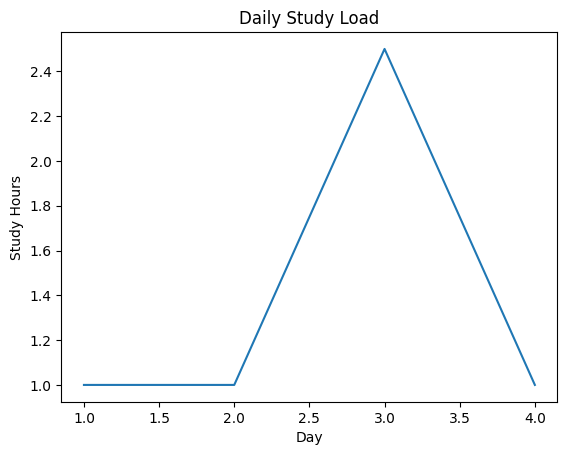

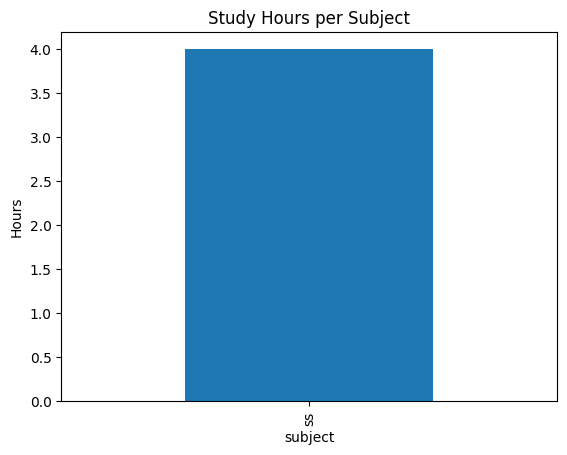


✅ Saved as study_plan.csv


In [18]:
# Install libraries
!pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# USER INPUT
# -----------------------------
subjects = []

n = int(input("Enter number of subjects: "))

for i in range(n):
    print(f"\nSubject {i+1}")

    name = input("Name: ")
    deadline = int(input("Days left: "))
    hours = float(input("Total hours needed: "))
    difficulty = int(input("Difficulty (1-5): "))

    subjects.append({
        "name": name,
        "deadline": deadline,
        "hours": hours,
        "difficulty": difficulty
    })

print("\n✅ Subjects Entered:")
for s in subjects:
    print(s)

MAX_HOURS_PER_DAY = 24

# -----------------------------
# VALIDATION
# -----------------------------
total_required = sum(s["hours"] for s in subjects)
max_days = max(s["deadline"] for s in subjects)
max_possible = max_days * MAX_HOURS_PER_DAY

print(f"\nTotal Required: {total_required}")
print(f"Max Possible: {max_possible}")

if total_required > max_possible:
    print("⚠️ WARNING: Not enough time to complete all subjects!")

# -----------------------------
# PRIORITY
# -----------------------------
def prioritize(subjects):
    return sorted(subjects, key=lambda x: x["difficulty"]/x["deadline"], reverse=True)

# -----------------------------
# SCHEDULER
# -----------------------------
def generate_plan(subjects):
    plan = []
    subjects = prioritize(subjects)

    remaining = {s["name"]: s["hours"] for s in subjects}
    max_days = max(s["deadline"] for s in subjects)

    for day in range(1, max_days + 1):
        daily_total = 0

        subjects = sorted(subjects,
                          key=lambda x: (remaining[x["name"]] / x["deadline"]) * x["difficulty"],
                          reverse=True)

        for sub in subjects:
            if day > sub["deadline"]:
                continue
            if remaining[sub["name"]] <= 0:
                continue

            available = MAX_HOURS_PER_DAY - daily_total
            if available <= 0:
                break

            days_left = sub["deadline"] - day + 1
            required_today = remaining[sub["name"]] / days_left

            study_time = min(required_today, available)

            plan.append({
                "day": day,
                "subject": sub["name"],
                "hours": study_time,
                "type": "study"
            })

            remaining[sub["name"]] -= study_time
            daily_total += study_time

    return plan

# -----------------------------
# REVISION
# -----------------------------
def add_revision(plan, subjects):
    new_plan = plan.copy()

    for sub in subjects:
        rev_day = sub["deadline"] - 1
        if rev_day > 0:
            new_plan.append({
                "day": rev_day,
                "subject": sub["name"],
                "hours": 1.5,
                "type": "revision"
            })

    return new_plan

# -----------------------------
# GENERATE PLAN
# -----------------------------
plan = generate_plan(subjects)
plan = add_revision(plan, subjects)

df = pd.DataFrame(plan)
df = df.sort_values(by="day")
df.reset_index(drop=True, inplace=True)

# -----------------------------
# FINAL CORRECTION (exact hours)
# -----------------------------
for sub in subjects:
    name = sub["name"]
    required = sub["hours"]

    mask = (df["subject"] == name) & (df["type"] == "study")
    actual = df[mask]["hours"].sum()

    diff = required - actual

    if abs(diff) > 0.0001:
        last_idx = df[mask].index[-1]
        df.at[last_idx, "hours"] += diff

df["hours"] = df["hours"].round(2)

# -----------------------------
# VERIFY
# -----------------------------
print("\n✅ STUDY HOURS CHECK:")
print(df[df["type"] == "study"].groupby("subject")["hours"].sum())

# -----------------------------
# SUBJECT-WISE ANALYTICS
# -----------------------------
print("\n📊 SUBJECT-WISE TOTAL:")
print(df.groupby("subject")["hours"].sum())

print("\n📊 STUDY vs REVISION:")
print(df.groupby(["subject", "type"])["hours"].sum())

summary = df.groupby(["subject", "type"])["hours"].sum().unstack().fillna(0)
summary["total"] = summary.sum(axis=1)

print("\n📋 CLEAN SUMMARY:")
display(summary)

# -----------------------------
# COMPLETION %
# -----------------------------
print("\n📈 COMPLETION %:")

for sub in subjects:
    name = sub["name"]
    required = sub["hours"]

    actual = df[(df["subject"] == name) & (df["type"] == "study")]["hours"].sum()

    percent = (actual / required) * 100

    print(f"{name}: {round(percent,2)}%")

# -----------------------------
# DISPLAY PLAN
# -----------------------------
print("\n===== STUDY PLAN =====\n")
display(df)

# -----------------------------
# DAY-WISE OUTPUT
# -----------------------------
for day in sorted(df["day"].unique()):
    print(f"\n📅 Day {day}")
    tasks = df[df["day"] == day]

    for _, row in tasks.iterrows():
        print(f"{row['subject']} - {row['hours']} hrs ({row['type']})")

# -----------------------------
# VISUALIZATION
# -----------------------------
daily_hours = df.groupby("day")["hours"].sum()

plt.figure()
plt.plot(daily_hours)
plt.xlabel("Day")
plt.ylabel("Study Hours")
plt.title("Daily Study Load")
plt.show()

summary["study"].plot(kind="bar")
plt.title("Study Hours per Subject")
plt.ylabel("Hours")
plt.show()

# -----------------------------
# SAVE FILE
# -----------------------------
df.to_csv("study_plan.csv", index=False)

print("\n✅ Saved as study_plan.csv")

## Output

The system generates:

- Day-wise study schedule
- Subject-wise hour distribution
- Visual representation of workload
- Downloadable study plan (CSV)